# **Reporte Final - Deep Learning**
- Maria Camila Jaramillo - maria.jaramillos@udea.edu.co
- Kimberly Jovana Tirado - kimberly.tirado@udea.edu.co

## **Descripción y Contextualización del Problema**

Hoy en día, plataformas como IMDb generan una gran cantidad de reseñas escritas por usuarios. Determinar de forma automática si una reseña expresa una opinión positiva o negativa es una tarea de gran valor práctico: permite a las plataformas entender la recepción del público, a los estudios cinematográficos medir el impacto de sus producciones y a los sistemas de recomendación ofrecer mejores sugerencias a sus usuarios.

### Objetivos
Desarrollar, implementar y evaluar diferentes modelos de deep learning para la clasificación binaria de sentimientos en reseñas de texto, utilizando embeddings pre-entrenados GloVe como técnica de transfer learning, con el fin de analizar la capacidad de distintas arquitecturas (Conv1D, LSTM y GRU) para capturar patrones semánticos y contextuales del lenguaje natural y determinar su efectividad en la predicción de opiniones positivas o negativas.

Objetivos específicos

- Preprocesar el texto de las reseñas mediante limpieza, tokenización, padding y construcción del vocabulario.
- Incorporar embeddings pre-entrenados GloVe para representar las palabras en un espacio vectorial semántico (transfer learning).
- Entrenar y evaluar un modelo con arquitectura Conv1D + GloVe para la clasificación de sentimientos.
- Entrenar y evaluar un modelo con arquitectura LSTM + GloVe para la clasificación de sentimientos.
- Entrenar y evaluar un modelo con arquitectura GRU + GloVe para la clasificación de sentimientos.
- Comparar el desempeño de los modelos utilizando métricas como accuracy, precision, recall y F1-score, analizando sus diferencias y capacidades para capturar información del texto.

##**Descripción de la base de datos**
El dataset utilizado en este trabajo es IMDB Movie Review, disponible en HuggingFace. Sus caracteristicas principales son:
- Tipo de datos: texto (reseñas de usuarios)
- Número de muestras: 50.000 (25,000 de entrenamiento y 25,000 de prueba)
- Idioma: inglés
- Longitud variable: las reseñas pueden ir desde pocas palabras hasta varios párrafos
- Etiquetas: Positiva (1) o negativa (0), balanceadas al 50%
- Fuente: Disponible en HuggingFace Datasets (stanfordnlp/imdb)


## **Diseño Experimental**

### Etapas del trabajo

- Preparación de datos: Carga del dataset completo, limpieza del texto (eliminación de etiquetas HTML, stopwords y caracteres especiales), tokenización con el Tokenizer de Keras (reservando el índice 0 para padding), padding de secuencias a longitud fija, y carga de embeddings GloVe para construir la matriz de embeddings alineada con el vocabulario.

- Experimento 1 - Conv1D + GloVe: Modelo con capas convolucionales 1D, BatchNormalization y GlobalMaxPooling1D. Los embeddings GloVe se mantienen congelados (no entrenables).

- Experimento 2 - LSTM + GloVe: Modelo con capa LSTM, BatchNormalization y capas densas. Los embeddings GloVe se mantienen congelados.

- Experimento 3 - GRU + GloVe: Modelo con capa GRU, BatchNormalization y capas densas. Misma configuración base que la LSTM para una comparación justa.

- Evaluación y comparación: Los tres modelos se evalúan sobre el mismo conjunto de prueba usando accuracy, precision, recall y F1-score. Se incluye una tabla resumen y visualizaciones comparativas.

### Métricas de evaluación

- Accuracy: Porcentaje de reseñas clasificadas correctamente. Es la métrica principal dado que el dataset está balanceado.
- Precision: De todas las reseñas que el modelo predijo como positivas, ¿cuántas realmente lo eran?
- Recall: De todas las reseñas realmente positivas, ¿cuántas detectó el modelo?
- F1-Score: Permite evaluar el equilibrio del modelo entre detectar correctamente las clases positivas y evitar errores.
- Curvas de pérdida y accuracy por época: Para analizar el proceso de entrenamiento y detectar posible overfitting.

## **Instalacion de librerias y preparación de los datos**

In [ ]:
# Instalamos la librería de HuggingFace para cargar el dataset IMDB
!pip install datasets -q

import os
import random

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import requests
import zipfile
import io

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    LSTM, GRU, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

from datasets import load_dataset

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from huggingface_hub.utils import logging as hf_logging
hf_logging.set_verbosity_error()

# Fijamos todas las semillas para reproducibilidad
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Función para resetear semillas antes de cada modelo
def resetear_semilla(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Cargamos el dataset completo, el cual ya viene dividido en train (25,000) y test (25,000)
dataset_train = load_dataset('stanfordnlp/imdb', split='train')
dataset_test  = load_dataset('stanfordnlp/imdb', split='test')

df_train = pd.DataFrame(dataset_train)
df_test  = pd.DataFrame(dataset_test)

print('Tamaño del conjunto de entrenamiento:', df_train.shape)
print('Tamaño del conjunto de prueba:        ', df_test.shape)
print('\nDistribución de clases en entrenamiento:')
print(df_train['label'].value_counts())

Tamaño del conjunto de entrenamiento: (25000, 2)
Tamaño del conjunto de prueba:         (25000, 2)

Distribución de clases en entrenamiento:
label
0    12500
1    12500
Name: count, dtype: int64


In [ ]:
df_train.head(10)

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0
5,I would put this at the top of my list of film...,0
6,Whoever wrote the screenplay for this movie ob...,0
7,"When I first saw a glimpse of this movie, I qu...",0
8,"Who are these ""They""- the actors? the filmmake...",0
9,This is said to be a personal film for Peter B...,0


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


El dataset IMDB contiene etiquetas HTML, signos de puntuación y stopwords que no aportan significado. Eliminar estos elementos ayuda al modelo a concentrarse en las palabras que realmente contienen información sobre el sentimiento de la reseña.

In [ ]:
# Cargamos las stopwords del inglés
stop_words_en = stopwords.words('english')

def limpiar_texto(texto):
    # Eliminamos etiquetas HTML como <br />
    texto = re.sub(r'<.*?>', ' ', texto)
    # Convertimos todo a minúsculas
    texto = texto.lower()
    # Eliminamos caracteres especiales y números, dejando solo letras y espacios
    texto = re.sub(r'[^a-z\s]', '', texto)
    # Tokenizamos y eliminamos stopwords y palabras de una sola letra
    palabras = nltk.word_tokenize(texto)
    palabras = [p for p in palabras if p not in stop_words_en and len(p) > 1]
    return palabras

train_limpio = [limpiar_texto(t) for t in df_train['text'].values]
test_limpio  = [limpiar_texto(t) for t in df_test['text'].values]

El tokenizador asigna un número entero único a cada palabra del vocabulario. Luego el padding garantiza que todas las secuencias tengan la misma longitud, rellenando con ceros las más cortas.

El índice 0 se reserva para el token de padding <pad>. Los demás índices empiezan desde 1. Esto es fundamental para que los pesos de GloVe queden bien alineados con el vocabulario del tokenizador.

In [ ]:
# Hiperparámetros de preprocesamiento
max_features = 10000  # Las 10,000 palabras más frecuentes del vocabulario
max_len      = 200    # Longitud máxima de cada secuencia
embed_din   = 50     # Dimensión de los embeddings GloVe

# Creamos el tokenizador y lo entrenamos SOLO con los datos de entrenamiento
tokenizer = Tokenizer(num_words=max_features, split=' ')
tokenizer.fit_on_texts(train_limpio)

# Reservamos el índice 0 para el token de padding
tokenizer.word_index = {w: i for w, i in tokenizer.word_index.items() if i < max_features}
tokenizer.word_index['<pad>'] = 0

# Convertimos los textos a secuencias de números
X_train_seq = tokenizer.texts_to_sequences(train_limpio)
X_test_seq  = tokenizer.texts_to_sequences(test_limpio)

# Aplicamos padding: rellenamos con ceros al final
X_train = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post')

# Las etiquetas ya son 0 y 1, las convertimos a arrays de NumPy
y_train = df_train['label'].values
y_test  = df_test['label'].values

print('Tamaño del vocabulario:', len(tokenizer.word_index))
print('Índice del token <pad>:', tokenizer.word_index.get('<pad>'))
print('Índice mínimo:', min(tokenizer.word_index.values()))
print('Índice máximo:', max(tokenizer.word_index.values()))

Tamaño del vocabulario: 10000
Índice del token <pad>: 0
Índice mínimo: 0
Índice máximo: 9999


## **Carga de Embeddings GloVe**
GloVe (Global Vectors for Word Representation) es un conjunto de vectores pre-entrenados desarrollado por Stanford. Cada palabra tiene asociado un vector numérico que captura su significado semántico: palabras con significados similares quedan cerca en el espacio vectorial. En este trabajo usamos la versión de 50 dimensiones entrenada sobre tweets de Twitter.

In [ ]:
# Descargamos los vectores GloVe pre-entrenados de Twitter
url = 'http://nlp.stanford.edu/data/glove.twitter.27B.zip'
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall('glove_twitter')

# Cargamos el archivo de 50 dimensiones en un diccionario
embeddings_index = {}
with open('glove_twitter/glove.twitter.27B.50d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

print(f'Total de vectores GloVe cargados: {len(embeddings_index):,}')

Total de vectores GloVe cargados: 1,193,514


In [ ]:
# Construimos la matriz de embeddings alineada con nuestro vocabulario

vocab_size = max_features
embedding_matrix = np.zeros((vocab_size, embed_din))

encontradas     = 0
no_encontradas  = 0

for word, idx in tokenizer.word_index.items():
    if idx < vocab_size:
         vector = embeddings_index.get(word)
         if vector is not None:
              embedding_matrix[idx] = vector
              encontradas += 1
         else:
              embedding_matrix[idx] = embeddings_index.get('unk', np.zeros(embed_din))
              no_encontradas += 1

print(f'Palabras encontradas en GloVe:     {encontradas}')
print(f'Palabras NO encontradas (usó unk): {no_encontradas}')
print(f'\nForma de la matriz de embeddings:  {embedding_matrix.shape}')

Palabras encontradas en GloVe:     9877
Palabras NO encontradas (usó unk): 123

Forma de la matriz de embeddings:  (10000, 50)


## **Experimento 1: Conv1D + GloVe**

La arquitectura Conv1D aplica filtros convolucionales sobre la secuencia de palabras con el fin de detectar patrones locales en el texto. El modelo fue implementado utilizando la API Sequential de Keras, lo que permite definir la arquitectura de forma más simple y ordenada, sin alterar su funcionamiento. Esta elección facilita la lectura del modelo y mantiene la coherencia en la presentación de los resultados.

In [ ]:
resetear_semilla()

def construir_conv1d(vocab_size, embed_dim, embedding_matrix, max_len, filtros=64):

    modelo = Sequential(name='Conv1D_GloVe')

    # Embedding con pesos GloVe congelados
    modelo.add(Embedding(input_dim=vocab_size,
                         output_dim=embed_dim,
                         weights=[embedding_matrix],
                         trainable=False,
                         input_shape=(max_len,),
                         name='embedding_glove'))

    modelo.add(Conv1D(filters=filtros, kernel_size=3, activation='relu',
                      padding='same', name='conv1d_trigrama'))
    modelo.add(BatchNormalization(name='bn_1'))

    modelo.add(Conv1D(filters=filtros // 2, kernel_size=5, activation='relu',
                      padding='same', name='conv1d_pentagrama'))
    modelo.add(BatchNormalization(name='bn_2'))

    modelo.add(GlobalMaxPooling1D(name='global_max_pool'))
    modelo.add(Dense(64, activation='relu', name='dense_1'))
    modelo.add(Dropout(0.3, name='dropout'))
    modelo.add(Dense(1, activation='sigmoid', name='salida'))

    return modelo


modelo_conv1d = construir_conv1d(vocab_size, embed_din, embedding_matrix, max_len)
modelo_conv1d.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
modelo_conv1d.summary()

Model: "Conv1D_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_glove (Embedding)     │ (None, 200, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_trigrama (Conv1D)        │ (None, 200, 64)        │         9,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 200, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_pentagrama (Conv1D)      │ (None, 200, 32)        │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 200, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,497 (1.99 MB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 500,192 (1.91 MB)

In [ ]:
# Entrenamiento
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

historia_conv1d = modelo_conv1d.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.7058 - loss: 0.5930 - val_accuracy: 0.7676 - val_loss: 0.4889
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8090 - loss: 0.4226 - val_accuracy: 0.6792 - val_loss: 0.6386
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8349 - loss: 0.3796 - val_accuracy: 0.8596 - val_loss: 0.3218
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8511 - loss: 0.3484 - val_accuracy: 0.8416 - val_loss: 0.3575
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8665 - loss: 0.3174 - val_accuracy: 0.7832 - val_loss: 0.4933


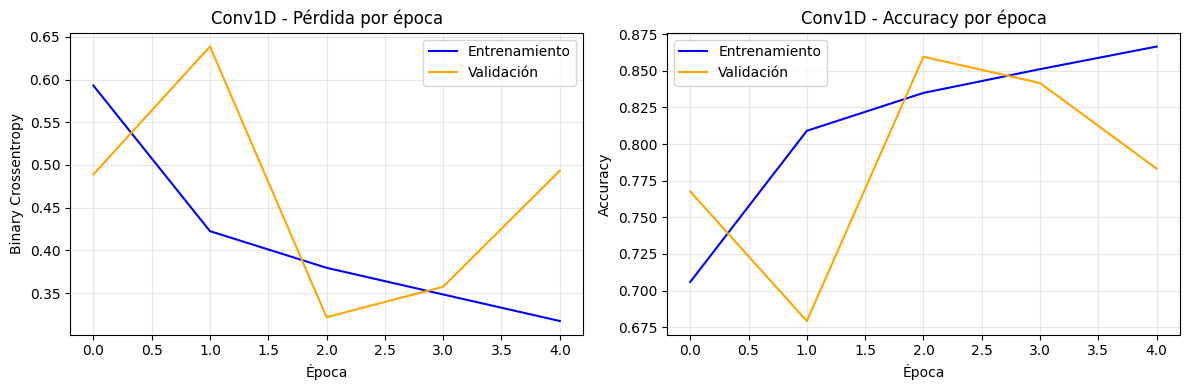

In [ ]:
# Visualizamos las curvas de pérdida y accuracy durante el entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historia_conv1d.history['loss'],     label='Entrenamiento', color='blue')
axes[0].plot(historia_conv1d.history['val_loss'], label='Validación',    color='orange')
axes[0].set_title('Conv1D - Pérdida por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historia_conv1d.history['accuracy'],     label='Entrenamiento', color='blue')
axes[1].plot(historia_conv1d.history['val_accuracy'], label='Validación',    color='orange')
axes[1].set_title('Conv1D - Accuracy por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

El modelo Conv1D aprende correctamente, ya que la pérdida de entrenamiento disminuye y el accuracy aumenta de forma constante. Sin embargo, las métricas de validación presentan variaciones, especialmente en las primeras épocas.

A partir de la época 2 se observa el mejor desempeño en validación, y luego aparece una ligera separación con respecto al entrenamiento, lo que sugiere un sobreajuste leve, aunque el modelo mantiene un rendimiento aceptable.

     RESULTADOS - EXPERIMENTO CONV1D
  Accuracy:  0.8206
  Precision: 0.7963
  Recall:    0.8618
  F1-Score:  0.8277

Reporte detallado:
              precision    recall  f1-score   support

    Negativa       0.85      0.78      0.81     12500
    Positiva       0.80      0.86      0.83     12500

    accuracy                           0.82     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.82      0.82      0.82     25000



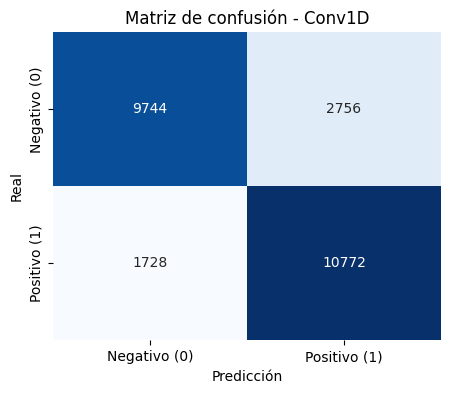

In [ ]:
# Evaluamos el modelo sobre el conjunto de prueba
# predict() devuelve probabilidades; las convertimos a etiquetas binarias con umbral 0.5
y_pred_prob_conv1d = modelo_conv1d.predict(X_test, batch_size=64, verbose=0)
y_pred_conv1d      = (y_pred_prob_conv1d >= 0.5).astype(int).flatten()

acc_conv1d  = accuracy_score(y_test,  y_pred_conv1d)
prec_conv1d = precision_score(y_test, y_pred_conv1d)
rec_conv1d  = recall_score(y_test,    y_pred_conv1d)
f1_conv1d   = f1_score(y_test,        y_pred_conv1d)

print('=' * 45)
print('     RESULTADOS - EXPERIMENTO CONV1D')
print('=' * 45)
print(f'  Accuracy:  {acc_conv1d:.4f}')
print(f'  Precision: {prec_conv1d:.4f}')
print(f'  Recall:    {rec_conv1d:.4f}')
print(f'  F1-Score:  {f1_conv1d:.4f}')
print('=' * 45)
print('\nReporte detallado:')
print(classification_report(y_test, y_pred_conv1d, target_names=['Negativa', 'Positiva']))

cm_conv1d = confusion_matrix(y_test, y_pred_conv1d)
plt.figure(figsize=(5,4))
sns.heatmap(cm_conv1d, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo (0)', 'Positivo (1)'],
            yticklabels=['Negativo (0)', 'Positivo (1)'],
            cbar=False)
plt.title("Matriz de confusión - Conv1D")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# Guardamos los resultados para la comparación final
resultados = {
    'Conv1D + GloVe': {
        'accuracy': acc_conv1d, 'precision': prec_conv1d,
        'recall': rec_conv1d,   'f1': f1_conv1d,
        'historia': historia_conv1d}}

El modelo Conv1D alcanza un desempeño general adecuado, con un accuracy de 0.82 y un F1-score de 0.83, lo que indica un buen equilibrio entre precisión y recall. En particular, el modelo identifica mejor las reseñas positivas (recall de 0.86) que las negativas (recall de 0.78), lo que sugiere una ligera tendencia a clasificar como positivas.

Esto se confirma en la matriz de confusión, donde se observan más falsos positivos (2756) que falsos negativos (1728). En general, el modelo presenta un rendimiento estable y consistente en ambas clases, aunque con margen de mejora en la identificación de reseñas negativa.

## **Experimento 2: LSTM + GloVe**

La arquitectura LSTM procesa la secuencia de palabras de manera secuencial, manteniendo un estado interno que funciona como memoria. Esto le permite conservar información de palabras anteriores y utilizarla para interpretar el contexto de las palabras siguientes. El modelo fue implementado utilizando la API Sequential de Keras, lo que permite una definición más clara y ordenada de la arquitectura, sin afectar su comportamiento ni desempeño.

In [ ]:
resetear_semilla()

def construir_lstm(vocab_size, embed_dim, embedding_matrix, max_len, unidades=64):

    modelo = Sequential(name='LSTM_GloVe')

    modelo.add(Embedding(input_dim=vocab_size,
                         output_dim=embed_dim,
                         weights=[embedding_matrix],
                         trainable=False,
                         mask_zero=True,
                         input_shape=(max_len,),
                         name='embedding_glove'))

    modelo.add(LSTM(units=unidades, name='lstm'))
    modelo.add(Dense(64, activation='relu', name='dense_1'))
    modelo.add(Dropout(0.3, name='dropout'))
    modelo.add(Dense(1, activation='sigmoid', name='salida'))

    return modelo


modelo_lstm = construir_lstm(vocab_size, embed_din, embedding_matrix, max_len)
modelo_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
modelo_lstm.summary()

Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_glove (Embedding)     │ (None, 200, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,665 (2.04 MB)

 Trainable params: 33,665 (131.50 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [ ]:
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

historia_lstm = modelo_lstm.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_lstm],
    verbose=1
)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7465 - loss: 0.5218 - val_accuracy: 0.7328 - val_loss: 0.6053
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8001 - loss: 0.4396 - val_accuracy: 0.7948 - val_loss: 0.4948
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8205 - loss: 0.4038 - val_accuracy: 0.8596 - val_loss: 0.3598
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.8354 - loss: 0.3786 - val_accuracy: 0.8588 - val_loss: 0.3792
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8438 - loss: 0.3607 - val_accuracy: 0.9012 - val_loss: 0.2845
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8536 - loss: 0.3434 - val_accuracy: 0.8900 - val_loss: 0.2955
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8626 - loss: 0.3282 - val_accuracy: 0.9052 - val_loss: 0.2633
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8680 - loss: 0.3130 - val_accu

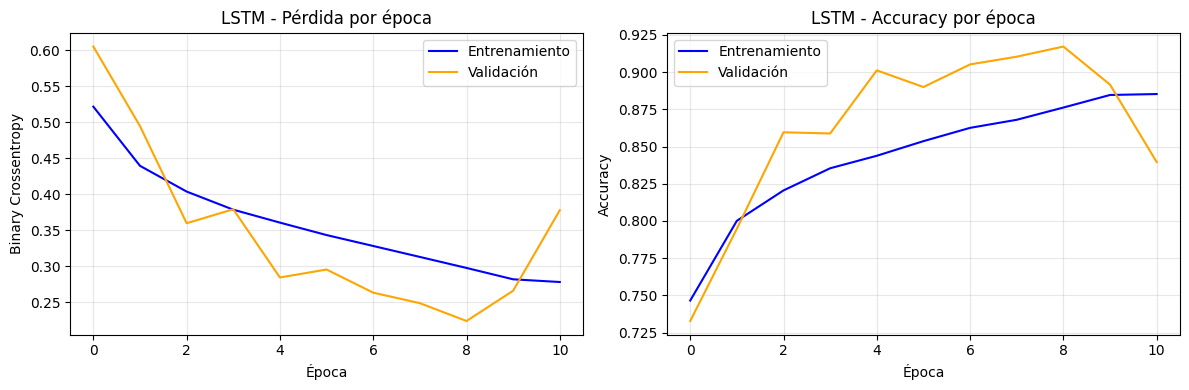

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historia_lstm.history['loss'],     label='Entrenamiento', color='blue')
axes[0].plot(historia_lstm.history['val_loss'], label='Validación',    color='orange')
axes[0].set_title('LSTM - Pérdida por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historia_lstm.history['accuracy'],     label='Entrenamiento', color='blue')
axes[1].plot(historia_lstm.history['val_accuracy'], label='Validación',    color='orange')
axes[1].set_title('LSTM - Accuracy por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

El modelo LSTM muestra un buen aprendizaje, con disminución de la pérdida y aumento del accuracy en entrenamiento. Además, el desempeño en validación es alto durante varias épocas.

Sin embargo, en las últimas épocas se observa un deterioro en la validación, lo que sugiere la aparición de sobreajuste leve, por lo que el mejor rendimiento se alcanza antes de finalizar el entrenamiento.

       RESULTADOS - EXPERIMENTO LSTM
  Accuracy:  0.8338
  Precision: 0.7831
  Recall:    0.9233
  F1-Score:  0.8475

Reporte detallado:
              precision    recall  f1-score   support

    Negativa       0.91      0.74      0.82     12500
    Positiva       0.78      0.92      0.85     12500

    accuracy                           0.83     25000
   macro avg       0.84      0.83      0.83     25000
weighted avg       0.84      0.83      0.83     25000



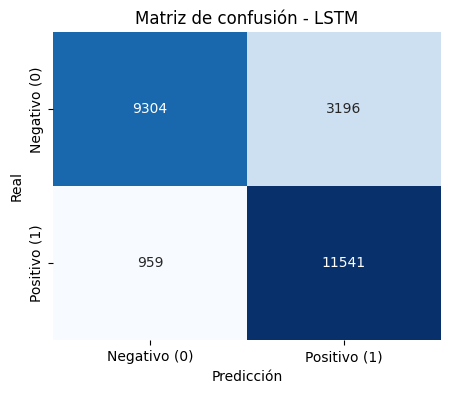

In [ ]:
y_pred_prob_lstm = modelo_lstm.predict(X_test, batch_size=64, verbose=0)
y_pred_lstm      = (y_pred_prob_lstm >= 0.5).astype(int).flatten()

acc_lstm  = accuracy_score(y_test,  y_pred_lstm)
prec_lstm = precision_score(y_test, y_pred_lstm)
rec_lstm  = recall_score(y_test,    y_pred_lstm)
f1_lstm   = f1_score(y_test,        y_pred_lstm)

print('=' * 45)
print('       RESULTADOS - EXPERIMENTO LSTM')
print('=' * 45)
print(f'  Accuracy:  {acc_lstm:.4f}')
print(f'  Precision: {prec_lstm:.4f}')
print(f'  Recall:    {rec_lstm:.4f}')
print(f'  F1-Score:  {f1_lstm:.4f}')
print('=' * 45)
print('\nReporte detallado:')
print(classification_report(y_test, y_pred_lstm, target_names=['Negativa', 'Positiva']))


cm_lstm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo (0)', 'Positivo (1)'],
            yticklabels=['Negativo (0)', 'Positivo (1)'],
            cbar=False)
plt.title("Matriz de confusión - LSTM")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


resultados['LSTM + GloVe'] = {
    'accuracy': acc_lstm, 'precision': prec_lstm,
    'recall': rec_lstm,   'f1': f1_lstm,
    'historia': historia_lstm
}

El modelo LSTM presenta un desempeño ligeramente superior al Conv1D, con un accuracy de 0.83 y un F1-score de 0.85, mostrando un buen equilibrio general. Destaca especialmente su capacidad para identificar reseñas positivas, con un recall alto de 0.92, aunque a costa de una menor detección de reseñas negativas (recall de 0.74).

Esto se refleja en la matriz de confusión, donde se observan más falsos positivos (3196) que falsos negativos (959), evidenciando una mayor tendencia a clasificar como positivas. En general, el modelo ofrece un buen rendimiento, aunque con menor precisión en la identificación de reseñas negativas en comparación con el modelo Conv1D.

## **Experimento 3: GRU + GloVe**

La arquitectura GRU es una red recurrente diseñada como una versión simplificada de la LSTM. A diferencia de esta, la GRU utiliza únicamente dos compuertas, lo que reduce la cantidad de parámetros y hace que el modelo sea más eficiente en términos computacionales. A pesar de esta simplificación, la GRU mantiene la capacidad de capturar dependencias secuenciales en el texto.

El modelo fue implementado utilizando la API Sequential de Keras, permitiendo una estructura clara y consistente sin afectar su desempeño.

In [ ]:
tf.keras.backend.clear_session()
resetear_semilla()

def construir_gru(vocab_size, embed_dim, embedding_matrix, max_len, unidades=64):

    modelo = Sequential(name='GRU_GloVe')

    # Embedding con GloVe
    modelo.add(Embedding(input_dim=vocab_size,
                         output_dim=embed_dim,
                         weights=[embedding_matrix],
                         trainable=False,
                         mask_zero=True,
                         input_shape=(max_len,),
                         name='embedding_glove'))

    # GRU
    modelo.add(GRU(units=unidades, name='gru'))

    modelo.add(Dense(64, activation='relu', name='dense_1'))
    modelo.add(BatchNormalization(name='bn'))
    modelo.add(Dropout(0.3, name='dropout'))

    modelo.add(Dense(1, activation='sigmoid', name='salida'))

    return modelo


modelo_gru = construir_gru(vocab_size, embed_din, embedding_matrix, max_len)
modelo_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
modelo_gru.summary()

Model: "GRU_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_glove (Embedding)     │ (None, 200, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn (BatchNormalization)         │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 526,753 (2.01 MB)

 Trainable params: 26,625 (104.00 KB)

 Non-trainable params: 500,128 (1.91 MB)

In [ ]:
early_stop_gru = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

historia_gru = modelo_gru.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_gru],
    verbose=1
)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7256 - loss: 0.5464 - val_accuracy: 0.8240 - val_loss: 0.4269
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8207 - loss: 0.4021 - val_accuracy: 0.8220 - val_loss: 0.4255
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8390 - loss: 0.3642 - val_accuracy: 0.8136 - val_loss: 0.4216
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8508 - loss: 0.3446 - val_accuracy: 0.8844 - val_loss: 0.2600
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8596 - loss: 0.3278 - val_accuracy: 0.8860 - val_loss: 0.2631
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8657 - loss: 0.3153 - val_accuracy: 0.8604 - val_loss: 0.3212


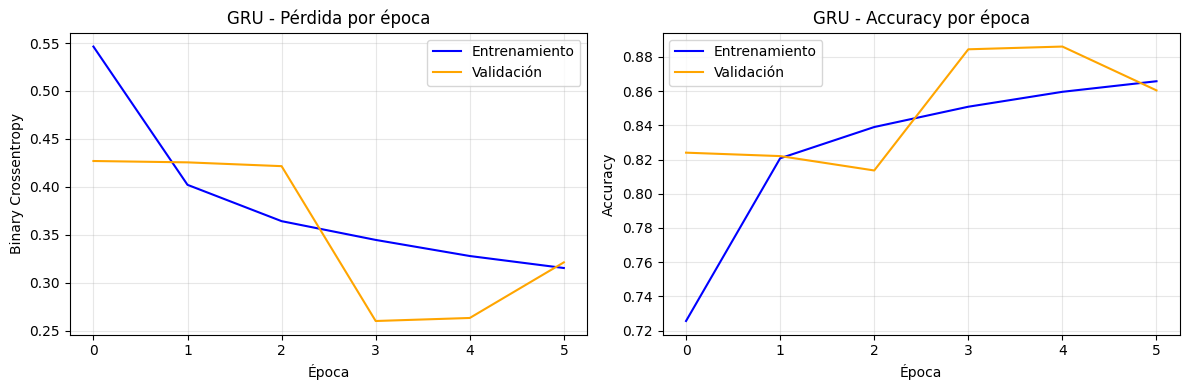

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historia_gru.history['loss'],     label='Entrenamiento', color='blue')
axes[0].plot(historia_gru.history['val_loss'], label='Validación',    color='orange')
axes[0].set_title('GRU - Pérdida por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historia_gru.history['accuracy'],     label='Entrenamiento', color='blue')
axes[1].plot(historia_gru.history['val_accuracy'], label='Validación',    color='orange')
axes[1].set_title('GRU - Accuracy por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

El modelo GRU muestra un aprendizaje adecuado, con una disminución progresiva de la pérdida y un aumento del accuracy en entrenamiento. En validación, el modelo alcanza su mejor desempeño entre las épocas 3 y 4.

Posteriormente, se observa una leve caída en el accuracy de validación, lo que sugiere un sobreajuste leve, aunque menos pronunciado que en otros modelos. En general, el GRU logra un buen equilibrio entre rendimiento y estabilidad.

        RESULTADOS - EXPERIMENTO GRU
  Accuracy:  0.8462
  Precision: 0.8109
  Recall:    0.9030
  F1-Score:  0.8545

Reporte detallado:
              precision    recall  f1-score   support

    Negativa       0.89      0.79      0.84     12500
    Positiva       0.81      0.90      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



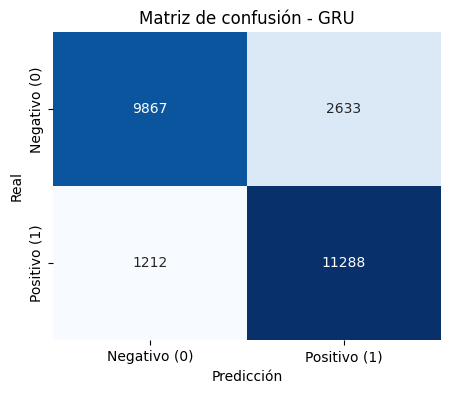

In [ ]:
y_pred_prob_gru = modelo_gru.predict(X_test, batch_size=64, verbose=0)
y_pred_gru      = (y_pred_prob_gru >= 0.5).astype(int).flatten()

acc_gru  = accuracy_score(y_test,  y_pred_gru)
prec_gru = precision_score(y_test, y_pred_gru)
rec_gru  = recall_score(y_test,    y_pred_gru)
f1_gru   = f1_score(y_test,        y_pred_gru)

print('=' * 45)
print('        RESULTADOS - EXPERIMENTO GRU')
print('=' * 45)
print(f'  Accuracy:  {acc_gru:.4f}')
print(f'  Precision: {prec_gru:.4f}')
print(f'  Recall:    {rec_gru:.4f}')
print(f'  F1-Score:  {f1_gru:.4f}')
print('=' * 45)
print('\nReporte detallado:')
print(classification_report(y_test, y_pred_gru, target_names=['Negativa', 'Positiva']))

cm_gru = confusion_matrix(y_test, y_pred_gru)
plt.figure(figsize=(5,4))
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo (0)', 'Positivo (1)'],
            yticklabels=['Negativo (0)', 'Positivo (1)'],
            cbar=False)
plt.title("Matriz de confusión - GRU")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

resultados['GRU + GloVe'] = {
    'accuracy': acc_gru, 'precision': prec_gru,
    'recall': rec_gru,   'f1': f1_gru,
    'historia': historia_gru
}

El modelo GRU presenta el mejor desempeño general, con un accuracy de 0.85 y un F1-score de 0.85, mostrando un buen equilibrio entre precision y recall. A diferencia de los otros modelos, logra un comportamiento más balanceado entre ambas clases, con valores similares en la clase negativa y positiva.

Esto se confirma en la matriz de confusión, donde los errores están más distribuidos (2633 falsos positivos y 1212 falsos negativos), indicando una menor tendencia a favorecer una clase sobre la otra. En general, el modelo GRU ofrece un rendimiento más estable y equilibrado, superando ligeramente a Conv1D y LSTM.

## **Conclusiones**

In [ ]:
# Construimos la tabla resumen con los resultados de los tres experimentos

modelos_nombres = ['Conv1D + GloVe', 'LSTM + GloVe', 'GRU + GloVe']

tabla = pd.DataFrame({
    'Modelo'   : modelos_nombres,
    'Accuracy' : [round(resultados[m]['accuracy'],  4) for m in modelos_nombres],
    'Precision': [round(resultados[m]['precision'], 4) for m in modelos_nombres],
    'Recall'   : [round(resultados[m]['recall'],    4) for m in modelos_nombres],
    'F1-Score' : [round(resultados[m]['f1'],        4) for m in modelos_nombres],
})

print('\n' + '=' * 65)
print('           TABLA COMPARATIVA DE RESULTADOS')
print('=' * 65)
print(tabla.to_string(index=False))
print('=' * 65)

mejor = tabla.loc[tabla['F1-Score'].idxmax(), 'Modelo']
print(f'\n Mejor modelo por F1-Score: {mejor}')


           TABLA COMPARATIVA DE RESULTADOS
        Modelo  Accuracy  Precision  Recall  F1-Score
Conv1D + GloVe    0.8206     0.7963  0.8618    0.8277
  LSTM + GloVe    0.8338     0.7831  0.9233    0.8475
   GRU + GloVe    0.8462     0.8109  0.9030    0.8545

 Mejor modelo por F1-Score: GRU + GloVe


En la comparación de modelos, se observa que el modelo GRU + GloVe obtiene el mejor desempeño general, alcanzando los valores más altos en accuracy (0.8462) y F1-score (0.8545). Esto indica un mejor equilibrio entre precision y recall frente a los otros modelos evaluados.

Por su parte, el modelo LSTM + GloVe destaca por su alto recall (0.9233), lo que refleja una mayor capacidad para identificar reseñas positivas, aunque con una ligera pérdida en precisión. Finalmente, el modelo Conv1D + GloVe presenta un rendimiento sólido y estable, aunque inferior en comparación con los modelos recurrentes. En conjunto, los resultados muestran que la arquitectura GRU logra el mejor balance entre desempeño y estabilidad.

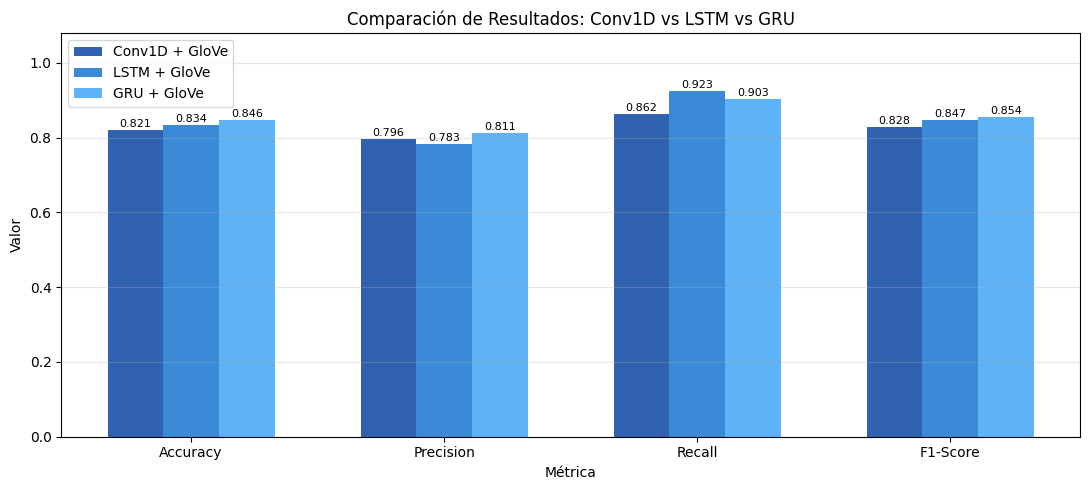

In [ ]:
# Gráfico de barras comparativo con las cuatro métricas

metricas   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colores    = ['#0D47A1', '#1976D2', '#42A5F5']
x          = np.arange(len(metricas))
ancho      = 0.22

fig, ax = plt.subplots(figsize=(11, 5))

for i, nombre in enumerate(modelos_nombres):
    vals = [
        resultados[nombre]['accuracy'],
        resultados[nombre]['precision'],
        resultados[nombre]['recall'],
        resultados[nombre]['f1']
    ]
    barras = ax.bar(x + (i - 1) * ancho, vals, ancho,
                    label=nombre, color=colores[i], alpha=0.85)
    for b in barras:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.003,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Métrica')
ax.set_ylabel('Valor')
ax.set_title('Comparación de Resultados: Conv1D vs LSTM vs GRU')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.08)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

La gráfica comparativa permite visualizar de forma clara las diferencias entre los modelos evaluados. Se observa que el modelo GRU + GloVe presenta el mejor desempeño general en la mayoría de métricas, mientras que el modelo LSTM + GloVe destaca en recall, indicando una mayor capacidad para identificar reseñas positivas. Por su parte, el modelo Conv1D + GloVe mantiene un comportamiento más estable, aunque con valores ligeramente inferiores. En conjunto, la gráfica confirma las tendencias observadas en la tabla comparativa.

## **Conclusiones**
En este trabajo se abordó el problema de clasificación de sentimientos en reseñas de texto utilizando diferentes arquitecturas de deep learning basadas en embeddings pre-entrenados GloVe. Se evaluaron tres enfoques principales: Conv1D, LSTM y GRU, comparando su desempeño mediante métricas como accuracy, precision, recall y F1-score.

Los resultados muestran que, aunque todos los modelos logran un buen desempeño, existen diferencias importantes en su comportamiento. El modelo Conv1D se caracteriza por su estabilidad, el LSTM por su alta capacidad para detectar reseñas positivas, y el GRU por ofrecer el mejor equilibrio entre las métricas evaluadas. En particular, el modelo GRU + GloVe obtuvo el mejor desempeño global, consolidándose como la alternativa más efectiva para esta tarea.

Finalmente, se evidenció la importancia de aplicar técnicas de regularización y ajustes de hiperparámetros para controlar el sobreajuste y mejorar la generalización de los modelos. En conjunto, este estudio permite concluir que la elección de la arquitectura influye significativamente en el rendimiento, siendo necesario un análisis comparativo para seleccionar el modelo más adecuado.